In [21]:
import os
import argparse

import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sb
import pandas as pd

from datatree import open_datatree
from scipy import stats
from scipy.stats import describe

from var_assim.plotting.presets import get_presets
from var_assim.plotting.bias_perc_error_over_time import make_cleaned_datatree_list
from var_assim.plotting.filtering import filter_by_max_conceivable
from var_assim.plotting.pproc import get_angle_r2, get_angles_for_dt_list
from var_assim.plotting.utils import make_figure_filename
from var_assim.config import PRIOR_PATH, NOISE_PATH, TRUTH_PATH, WINDOW_PATH, DATA_DIR_ABS, FIGS_DIR
from var_assim.calibration.priors import ClimateModelPriors
from var_assim.calibration.noise import ClimateModelNoise
from var_assim.calibration.truth import ClimateModelTruth
from var_assim.calibration.windowing import AssimilationWindowing

# enable auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
presets, basefile = get_presets()
plt.rcParams.update(presets)
SAVE_FIGS = True

In [3]:
# simulation config
cwd = os.getcwd()
prefix = 'var-assim-output'
ssp = 'ssp245'
model = 'pco2geowc'
reg_noise = False
TMIN = 2023
AR = '1'
angles_file = ['5', '11', '15', '21', '30', '35']
ECS = 3.0
DEGpDEC = '0.2'
NYRSRAMP = 50
windowing_config = 'ws_gradual'
Nens = 1000
first_wind = '2025'

# import files and convert to datatrees
if model == 'pco2geowc_nn':
    fnames = [
        DATA_DIR_ABS / 'output' / (model + '/' 
                        + prefix + '_' + ssp + '_' + model + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
                        + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nwinds' + Nwinds + '_Nens' + str(Nens) + '.nc')
        for th in angles_file
    ]

else:    
    fnames = [
        DATA_DIR_ABS / 'output' / (model + '/'
                        + prefix + '_' + ssp + '_' + model + '_' + windowing_config + '_AR' + AR
                        + '_TMIN' + str(TMIN) + '_THETA' + th + '_ECS' + str(ECS)
                        + '_DEGpDEC' + DEGpDEC + '_NYRSRAMP' + str(NYRSRAMP) + '_Nens' + str(Nens) + '.nc')
        for th in angles_file
    ]

In [4]:
cli_args = argparse.Namespace(
    model=model,
    ssp=ssp,
    noise_model=f"AR{AR}" if model != 'pco2geowc_nn' else 'nn',
    tmin=TMIN,
    AR=AR,
    ECS=ECS,
    DEGpDEC=DEGpDEC,
    NYRSRAMP=NYRSRAMP,
    Nens=Nens,
    reg_noise=reg_noise,
    windowing=windowing_config
)

Noise = ClimateModelNoise.from_cli_and_yaml(cli_args, NOISE_PATH)
Prior = ClimateModelPriors.from_cli_and_yaml_and_noise(cli_args, PRIOR_PATH, Noise)
Windowing = AssimilationWindowing.from_cli_and_yaml(cli_args, WINDOW_PATH)

In [5]:
dt_meta = open_datatree(fnames[0], engine='netcdf4')

In [6]:
relevant_vars = ['cost_hist', 'controls', 'controls_hist', 'obs', 'data_final', 'data_truth', 'controls_truth']
all_vars = [x for x in dt_meta[first_wind].ds.data_vars]
dropped_vars = [v for v in all_vars if v not in relevant_vars]
dropped_vars


['l2s', 'costs', 'data_hist', 'l2_hist', 'flag']

In [7]:
dts_clean = make_cleaned_datatree_list(fnames, angles_file, dropped_vars, THRESHOLD=1e-2)

Processing angle = 5...
Found 9 nodes in tree
Processing node 1: /2025
  Memory: 15.2 MB
  Result: 998 kept, 2 filtered
Processing node 2: /2030
  Memory: 20.1 MB
  Result: 990 kept, 10 filtered
Processing node 3: /2035
  Memory: 25.3 MB
  Result: 990 kept, 10 filtered
Processing node 4: /2040
  Memory: 31.0 MB
  Result: 987 kept, 13 filtered
Processing node 5: /2050
  Memory: 43.4 MB
  Result: 993 kept, 7 filtered
Processing node 6: /2060
  Memory: 57.4 MB
  Result: 995 kept, 5 filtered
Processing node 7: /2075
  Memory: 81.2 MB
  Result: 990 kept, 10 filtered
Processing node 8: /2100
  Memory: 128.6 MB
  Result: 996 kept, 4 filtered

Rebuilding tree with 8 filtered nodes...
✓ Filtering complete
Processing angle = 11...
Found 9 nodes in tree
Processing node 1: /2025
  Memory: 15.2 MB
  Result: 998 kept, 2 filtered
Processing node 2: /2030
  Memory: 20.1 MB
  Result: 990 kept, 10 filtered
Processing node 3: /2035
  Memory: 25.3 MB
  Result: 990 kept, 10 filtered
Processing node 4: /204

In [8]:
# important simulation constants
L_CEN = Prior.L_CEN
G_CEN = Prior.G_CEN
EPS_CEN = Prior.EPS_CEN
F_EFF_GEO = 0.09  # hard constant
ALPHA_R1_CEN = Prior.ALPHA_CEN[0]
ALPHA_R2_CEN = Prior.ALPHA_CEN[1]

In [9]:
dat = dts_clean[1]

In [10]:
angles_tr = np.zeros(6)

for idx, angle in enumerate(angles_file):
    tmp_cli = argparse.Namespace(
        model=model,
        ssp=ssp,
        noise_model=f"AR{AR}" if model != 'pco2geowc_nn' else 'nn',
        TMIN=TMIN,
        theta=float(angle),
        AR=AR,
        ecs=ECS,
        DEGpDEC=DEGpDEC,
        NYRSRAMP=NYRSRAMP,
        Nens=Nens,
        reg_noise=reg_noise
    )
    tmp_truth = ClimateModelTruth.from_cli_and_yaml(tmp_cli, TRUTH_PATH)

    angles_tr[idx] = get_angle_r2(
        tmp_truth.ALPHA_TR[0], tmp_truth.ALPHA_TR[1],
        tmp_truth.BETA_TR[0], tmp_truth.BETA_TR[1],
        tmp_truth.L_TR, tmp_truth.EPS_TR, tmp_truth.G_TR
    )

angles_tr

array([ 5., 11., 15., 21., 30., 35.])

In [11]:
# pull prior distributions
prior_a1 = dat[first_wind].ds.controls_hist.sel(vari='ALPHA_R1', iter=0).values
prior_b1 = dat[first_wind].ds.controls_hist.sel(vari='BETA_R1', iter=0).values
prior_a2 = dat[first_wind].ds.controls_hist.sel(vari='ALPHA_R2', iter=0).values
prior_b2 = dat[first_wind].ds.controls_hist.sel(vari='BETA_R2', iter=0).values
prior_l = dat[first_wind].ds.controls_hist.sel(vari='L', iter=0).values
prior_g = dat[first_wind].ds.controls_hist.sel(vari='G', iter=0).values
prior_eps = dat[first_wind].ds.controls_hist.sel(vari='EPS', iter=0).values

# compute priors
angles_prior = np.zeros(Nens)
for i in range(Nens):
    angles_prior[i] = get_angle_r2(prior_a1[i], prior_a2[i], prior_b1[i], prior_b2[i], prior_l[i], prior_eps[i], prior_g[i])

# describe for the people
describe(angles_prior)

DescribeResult(nobs=1000, minmax=(nan, nan), mean=nan, variance=nan, skewness=nan, kurtosis=nan)

In [12]:
winds = np.array([w[1] for w in Windowing.windows])
windss = [str(w) for w in winds]

In [13]:
angles = get_angles_for_dt_list(dts_clean, windss, Nens)

In [14]:
ANGLE_MAX_CONCEIVABLE = 70.
angles_filtered = filter_by_max_conceivable(angles, ANGLE_MAX_CONCEIVABLE)
angles_filtered.shape

(6, 8, 1000)

In [31]:
# prepare data for plotting
tr_, yr_, w_ = -1, '2050', 4  # choose true value index and assimilation year ('obs up to X')
ds = dts_clean[tr_][yr_].ds

angles_sel = angles_filtered[tr_, w_]

data = np.zeros((12, Nens))
data[0] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='L').values)
data[1] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='G').values)
data[2] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='EPS').values)
data[3] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='C1').values)
data[4] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='C2').values)
data[5] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='F1_CO2').values)
data[6] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='ALPHA_R1').values)
data[7] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='ALPHA_R2').values)
data[8] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='BETA_R1').values/0.09)
data[9] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, ds.controls.sel(vari='BETA_R2').values/0.09)
data[10] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, angles_sel)
data[11] = np.where(angles_sel > np.percentile(angles_prior, 95), 0, angles_prior)

data = np.zeros((12, Nens))
data[0] = ds.controls.sel(vari='L').values
data[1] = ds.controls.sel(vari='G').values
data[2] = ds.controls.sel(vari='EPS').values
data[3] = ds.controls.sel(vari='C1').values
data[4] = ds.controls.sel(vari='C2').values
data[5] = ds.controls.sel(vari='F1_CO2').values
data[6] = ds.controls.sel(vari='ALPHA_R1').values
data[7] = ds.controls.sel(vari='ALPHA_R2').values
data[8] = ds.controls.sel(vari='BETA_R1').values/0.09
data[9] = ds.controls.sel(vari='BETA_R2').values/0.09
data[10] = angles_sel
data[11] = angles_prior

In [32]:
df_all = pd.DataFrame(data=data.T,
    columns=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)', r'$\varepsilon$ ($-$)', r'$C_1$', r'$C_2$',
             r'$f^{(CO_2)}_1$ (W m$^{-2})$', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)',
             r'$\beta_{R1}$ (K / W m$^{-2}$)', r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta_{2050}$ (Degrees)', r'$\vartheta_{prior}$ (Degrees)']
)

saved figure to /project/bbcael/ambauer/learning_sai/analysis/figs/results/2026-07-01-corner-plot-th35-wind2050.png


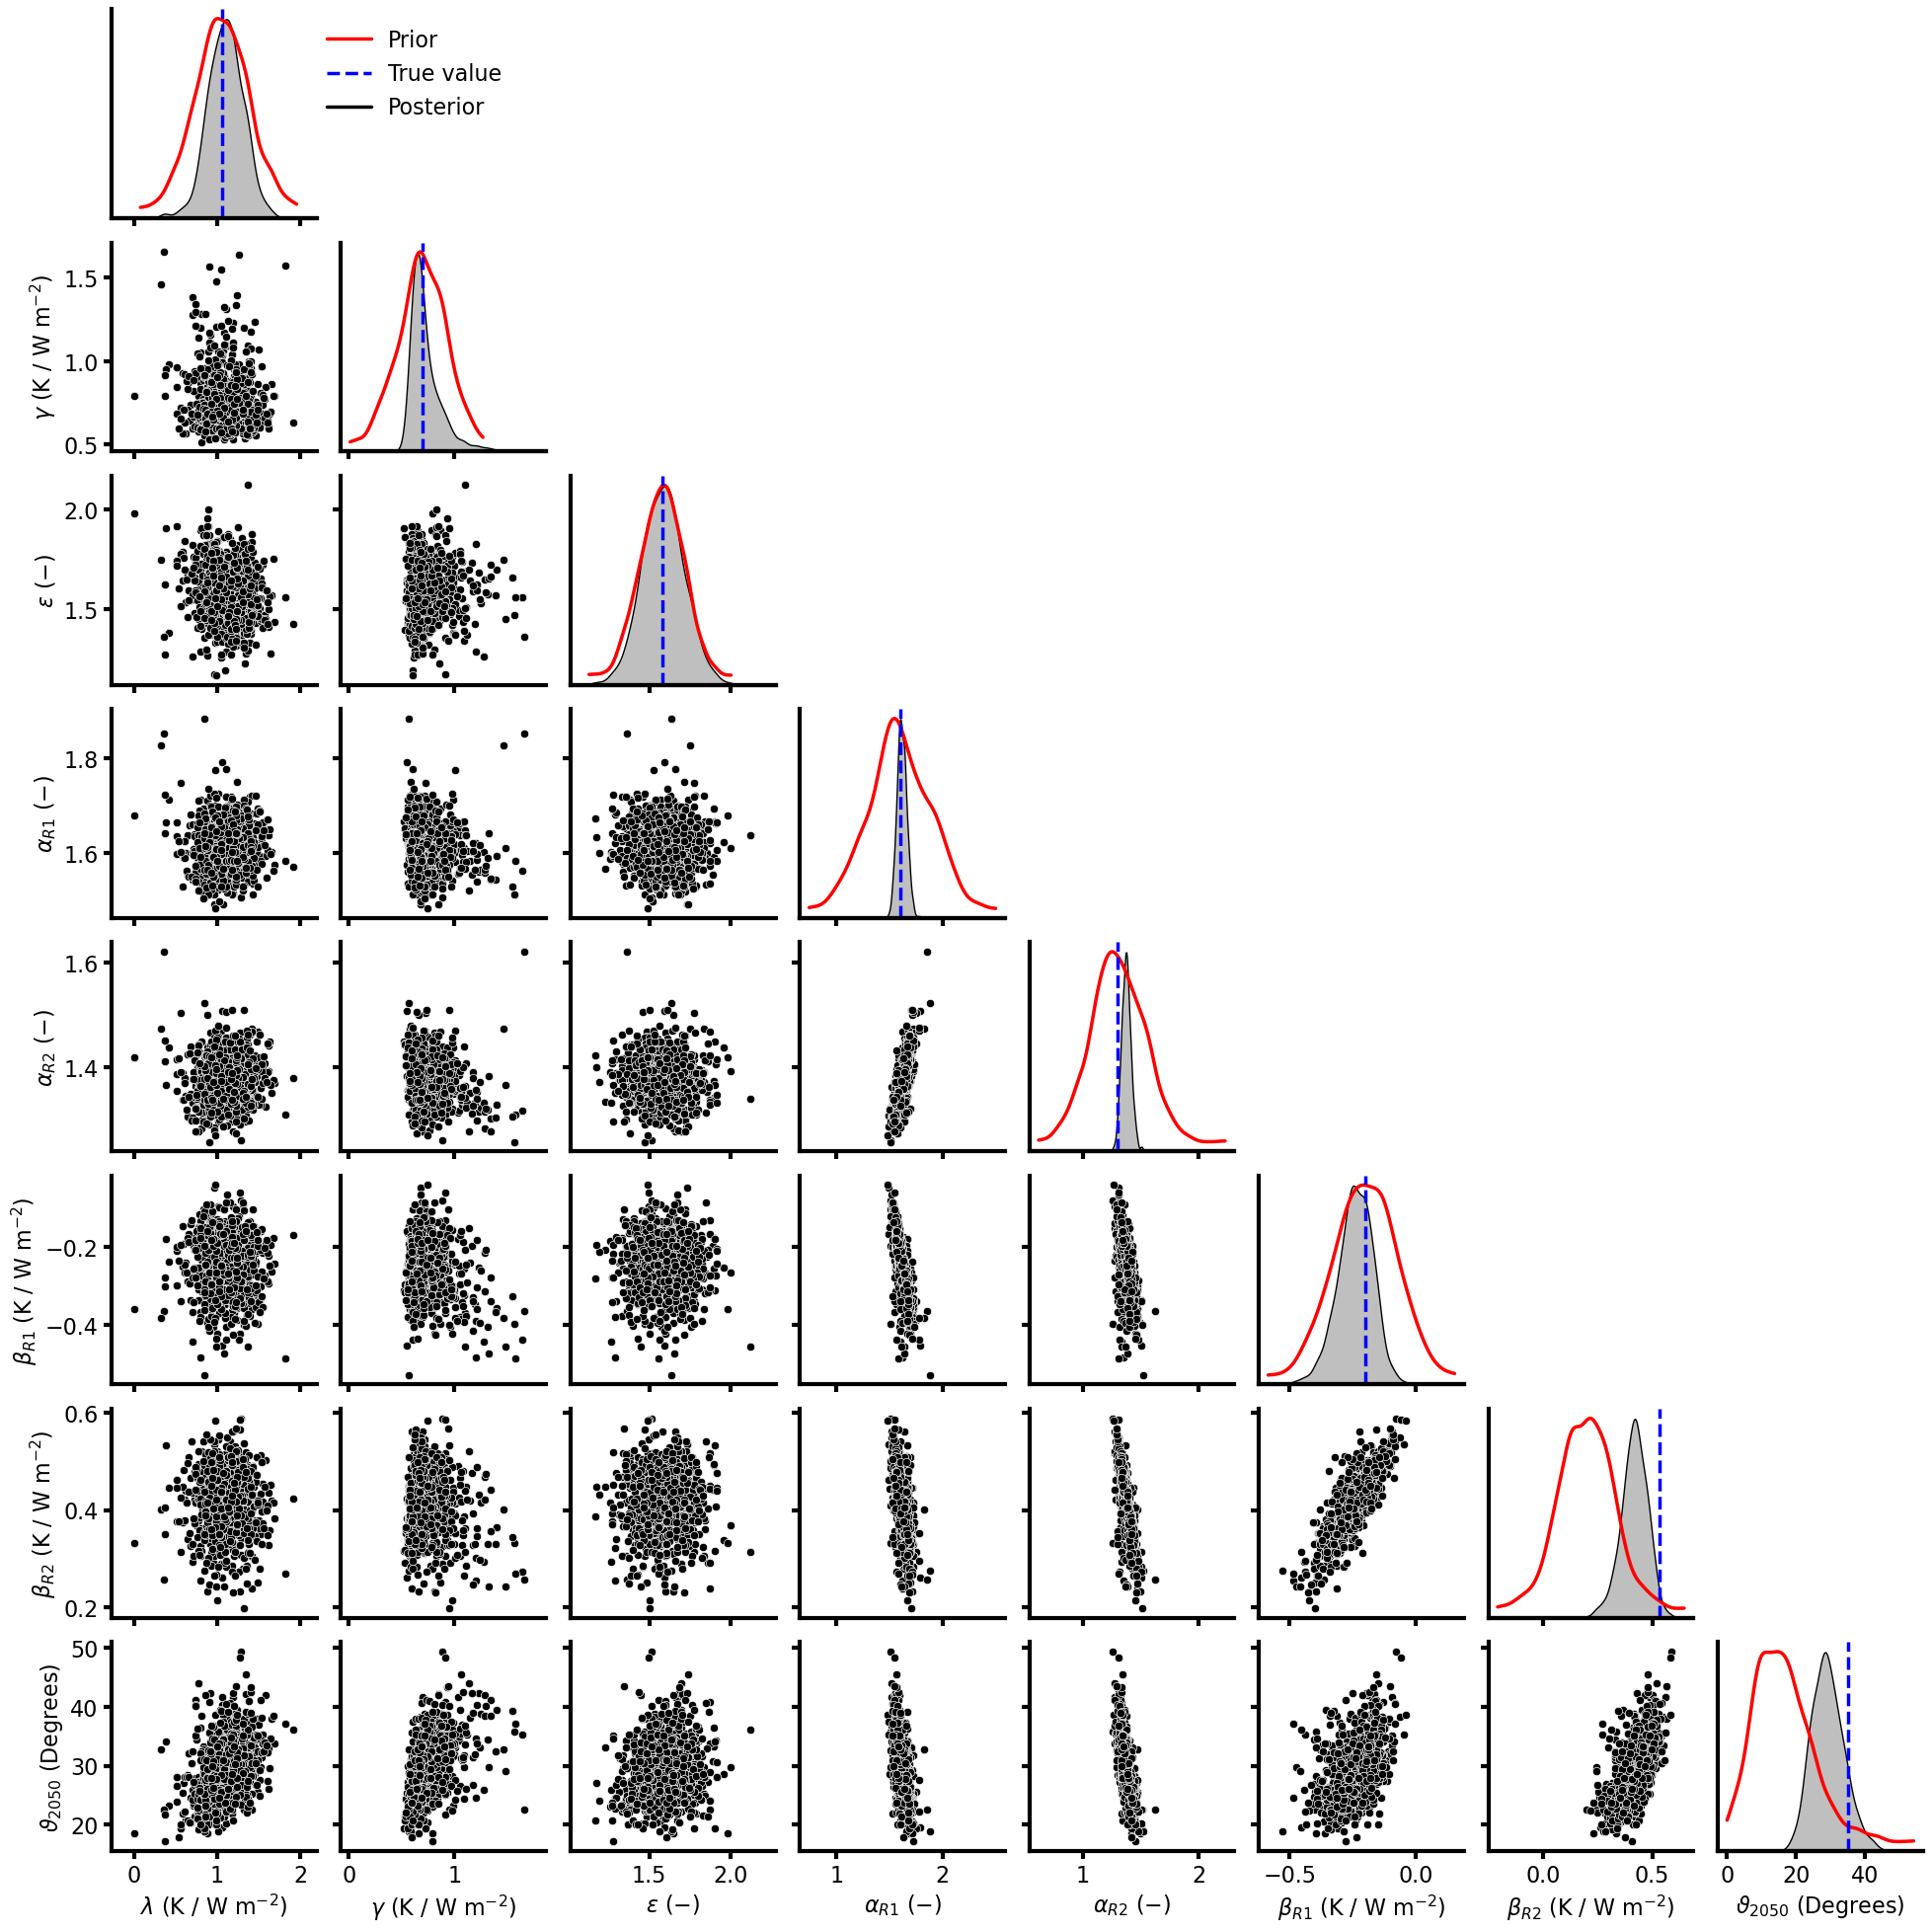

In [33]:
pp = sb.pairplot(df_all, vars=[r'$\lambda$ (K / W m$^{-2}$)', r'$\gamma$ (K / W m$^{-2}$)',
                               r'$\varepsilon$ ($-$)', r'$\alpha_{R1}$ ($-$)', r'$\alpha_{R2}$ ($-$)', r'$\beta_{R1}$ (K / W m$^{-2}$)', 
                               r'$\beta_{R2}$ (K / W m$^{-2}$)', r'$\vartheta_{2050}$ (Degrees)'],
                 diag_kind='kde', corner=True, dropna=True)

prior_f = np.random.normal(4.58, 0.519, size=500)
prior_samples = [prior_l, prior_g, prior_eps, prior_a1, prior_a2, prior_b1/0.09, prior_b2/0.09,
                 angles_prior]
beta_truth = [-0.0032434272616591047, 0.008869679826887949, 
              0.016202757620374424, 0.0264008212943374,
              0.040510647270981935, 0.04800215599496439]
var_truth = [L_CEN, G_CEN, 1.58, 1.6, 1.3,-0.01812132/0.09, beta_truth[tr_]/0.09, angles_tr[tr_]]

# add priors on the diagonals
for i, ax in enumerate(pp.diag_axes):
    # Mask NaNs
    samples = np.asarray(prior_samples[i])
    samples = samples[~np.isnan(samples)]

    x = np.linspace(samples.min(), samples.max(), 200)
    zeros = np.zeros_like(x)

    kde = stats.gaussian_kde(samples)

    ax2 = ax.twinx()
    ax2.plot(x, kde(x), 'r-', label='Prior', zorder=-1)
    ax2.axvline(var_truth[i], linestyle='dashed', color='b', label="True value")
    ax2.set_xlim(ax.get_xlim())

    # ax2.fill_between(x, zeros, kde(x), alpha=0.3, color='r', zorder=-1)

    ax2.set_ylabel('')
    ax2.set_yticks([])

    if i == 0:
        ax2.plot([2.0], [0], 'k-', label="Posterior")
        ax2.legend(bbox_to_anchor=(2.0, 1.0))

if SAVE_FIGS:
    filename = make_figure_filename(f'corner-plot-th{angles_file[tr_]}-wind{yr_}', FIGS_DIR / 'results')
    pp.savefig(filename)
    print(f"saved figure to {filename}")

plt.show()

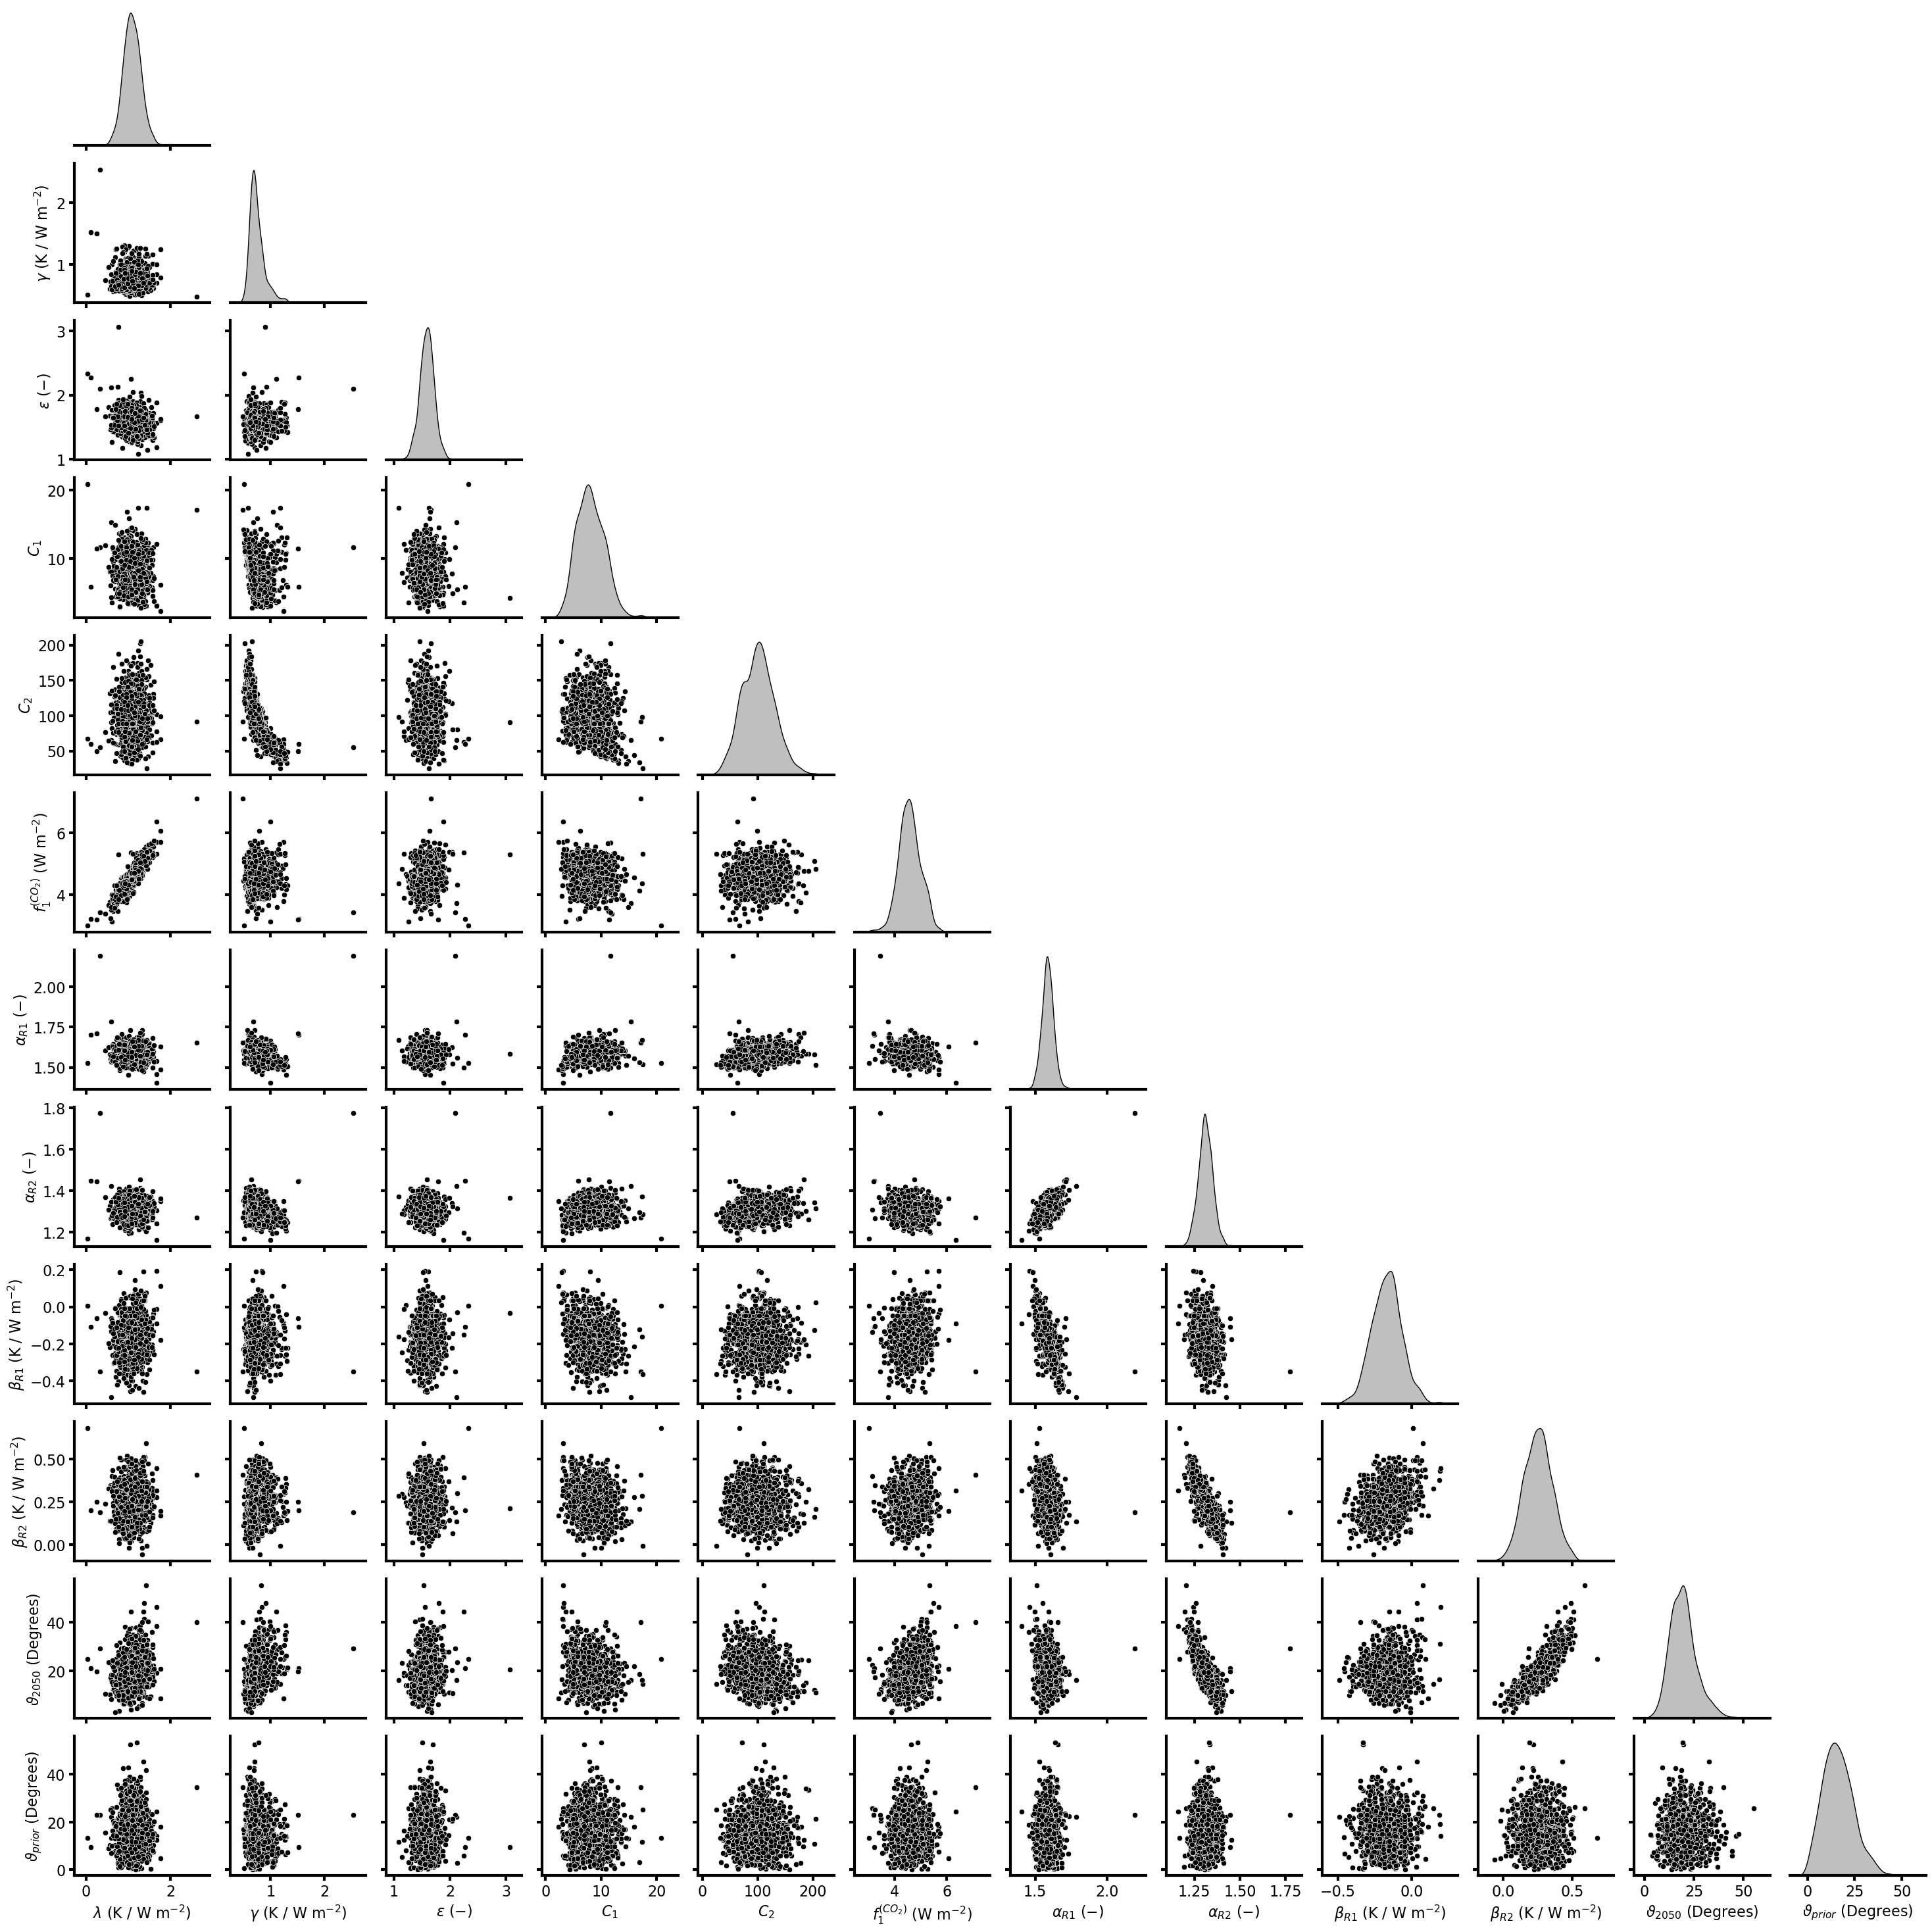

In [19]:
pp = sb.pairplot(df_all,
                diag_kind='kde', corner=True, dropna=True)

In [18]:
ds = dts_clean[-1]['2050'].ds
ds

<xarray.DatasetView>
Dimensions:          (ens_mem: 1000, vari: 43, time: 28, iter: 101, obs_var: 4)
Coordinates:
  * time             (time) int64 2023 2024 2025 2026 ... 2047 2048 2049 2050
  * iter             (iter) int64 0 1 2 3 4 5 6 7 8 ... 93 94 95 96 97 98 99 100
  * vari             (vari) object 'T1' 'T2' 'Q' 'T_R1' ... 'q25' 'q26' 'q27'
  * ens_mem          (ens_mem) int64 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * obs_var          (obs_var) object 'T1' 'Q' 'T_R1' 'T_R2'
Data variables:
    data_final       (ens_mem, vari, time) float64 0.7994 0.8202 ... -0.07411
    controls         (ens_mem, vari) float64 0.9376 0.1542 ... -0.2883 -0.07411
    cost_hist        (ens_mem, iter) float64 11.0 0.283 ... 0.05357 0.05355
    controls_hist    (ens_mem, vari, iter) float64 1.387 1.024 ... -0.07411
    obs              (obs_var, time) float64 0.7559 0.8397 ... 1.838 1.878
    data_truth       (vari, time) float64 0.7559 0.8397 0.8495 ... 0.137 0.137
    controls_truth   (vari) float64 0.9641 0.2734 35.05 ... -0.1129 0.1338 0.137
    cost_ratio_mask  (ens_mem) bool True True True True ... True True True True
Attributes: (12/24)
    reg_noise:               False
    model:                   pco2geowc
    tol:                     0.01
    debug:                   False
    n_yrs_ramp:              50
    tmin:                    2023
    ...                      ...
    filtered_by_cost_ratio:  True
    cost_ratio_threshold:    0.01
    cost_ratio_fill_value:   nan
    n_members_kept:          992
    n_members_filtered:      8
    filtered_node_path:      /2050

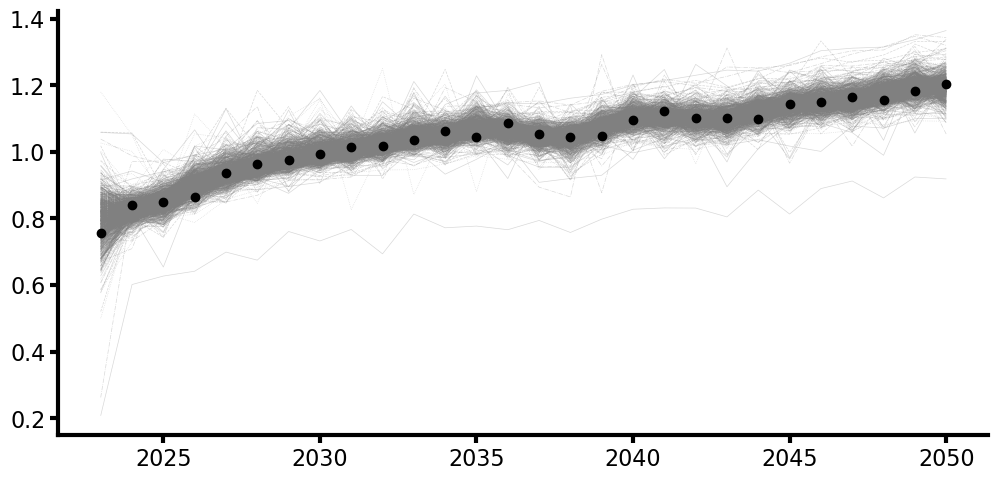

In [19]:
plt.scatter(ds.time, ds.sel(obs_var='T1').obs.values, zorder=100)

for i in range(Nens):
    plt.plot(ds.time, ds.sel(vari='T1', ens_mem=i).data_final.values, lw=0.5, alpha=0.3, color='grey')

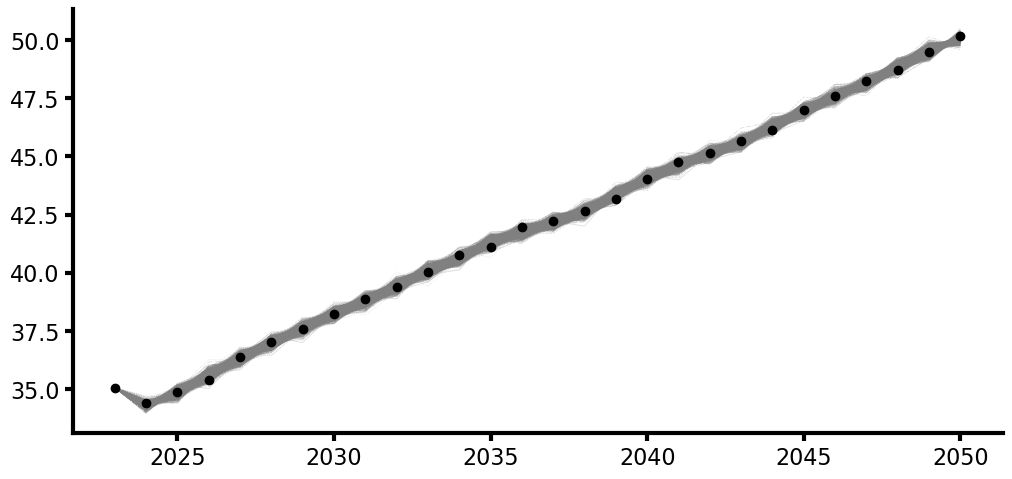

In [20]:
plt.scatter(ds.time, ds.sel(obs_var='Q').obs.values, zorder=100)

for i in range(Nens):
    plt.plot(ds.time, ds.sel(vari='Q', ens_mem=i).data_final.values, lw=0.5, alpha=0.3, color='grey')

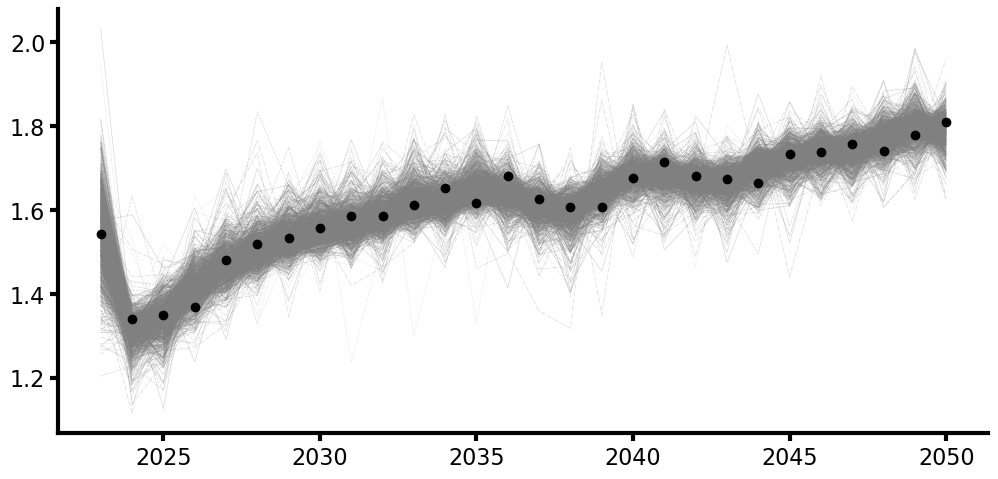

In [21]:
plt.scatter(ds.time, ds.sel(obs_var='T_R1').obs.values, zorder=100)

for i in range(Nens):
    plt.plot(ds.time, ds.sel(vari='T_R1', ens_mem=i).data_final.values, lw=0.5, alpha=0.3, color='grey')

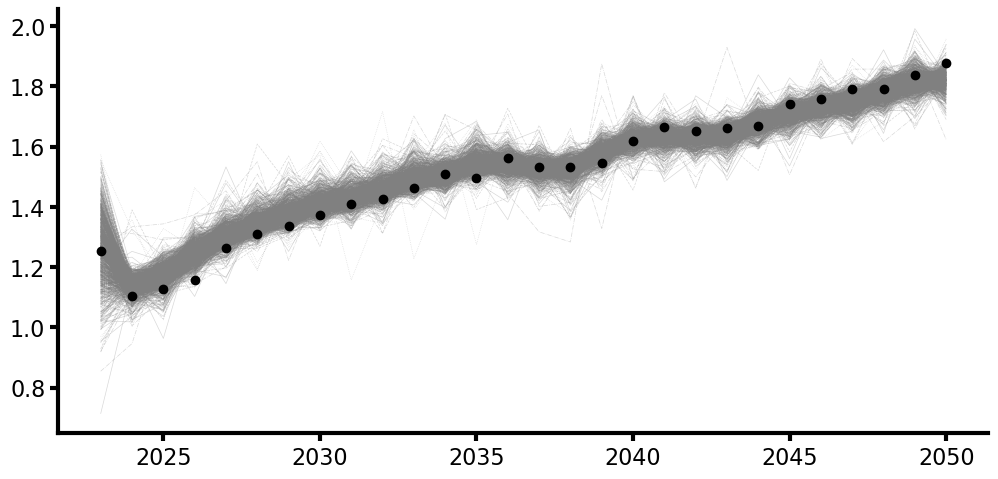

In [22]:
plt.scatter(ds.time, ds.sel(obs_var='T_R2').obs.values, zorder=100)

for i in range(Nens):
    plt.plot(ds.time, ds.sel(vari='T_R2', ens_mem=i).data_final.values, lw=0.5, alpha=0.3, color='grey')

In [23]:
ds.controls_truth.sel(vari=['q0', 'q1', 'q2'])

<xarray.DataArray 'controls_truth' (vari: 3)>
array([-0.20813 ,  0.08474 , -0.339367])
Coordinates:
  * vari     (vari) object 'q0' 'q1' 'q2'

In [ ]:
from scipy import stats
# Assuming your dataframe is called 'df'
theta_col = r'$\vartheta$ (Degrees)'

# Get the independent variable (theta)
theta = df_all[theta_col]

results = {}
r_tot = 0

# Loop through each column
for col in df_all.columns:
    # Skip the theta column itself
    if col == theta_col or col == 'ECS (K)' or col == 'TCR (K)':
        continue
    
    # Get the dependent variable
    y = df_all[col]
    
    # Remove NaN values
    mask = ~(np.isnan(theta) | np.isnan(y))
    theta_clean = theta[mask]
    y_clean = y[mask]
    
    # Perform linear regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        theta[mask], y[mask]
    )

    r_tot += r_value**2
    
    results[col] = {
        'slope': slope,
        'intercept': intercept,
        'r_squared': r_value**2,
        'p_value': p_value,
        'std_err': std_err
    }

# Convert to DataFrame and sort by R² (descending)
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('r_squared', ascending=False)

print(results_df)
print(f"\n\nVariables ranked by variance explained (R²):")
print("="*60)
for i, (var, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {var}")
    print(f"   R² = {row['r_squared']/r_tot:.4f} ({row['r_squared']*100/r_tot:.2f}% variance explained)")
    print(f"   Slope = {row['slope']:.4f}, p-value = {row['p_value']:.4e}\n")